\begin{equation}
\dot{w_1} = S_{11} w_1 + S_{12} w_2
\end{equation}

\begin{equation}
\varepsilon \dot{w_2} = S_{21} w_1 + S_{22} w_2
\end{equation}

Let's suppose both $w_1$ and $w_2$ are 2nd order systems, so the total signal is a 4th order system. 

[[   0.    1.    0.    0.]
 [   0.    0.    1.    0.]
 [   0.    0.    0.    2.]
 [-200.  -20. -100.   -1.]]
[-0.40301825+14.05913266j -0.40301825-14.05913266j
 -0.09698175 +1.41866771j -0.09698175 -1.41866771j]


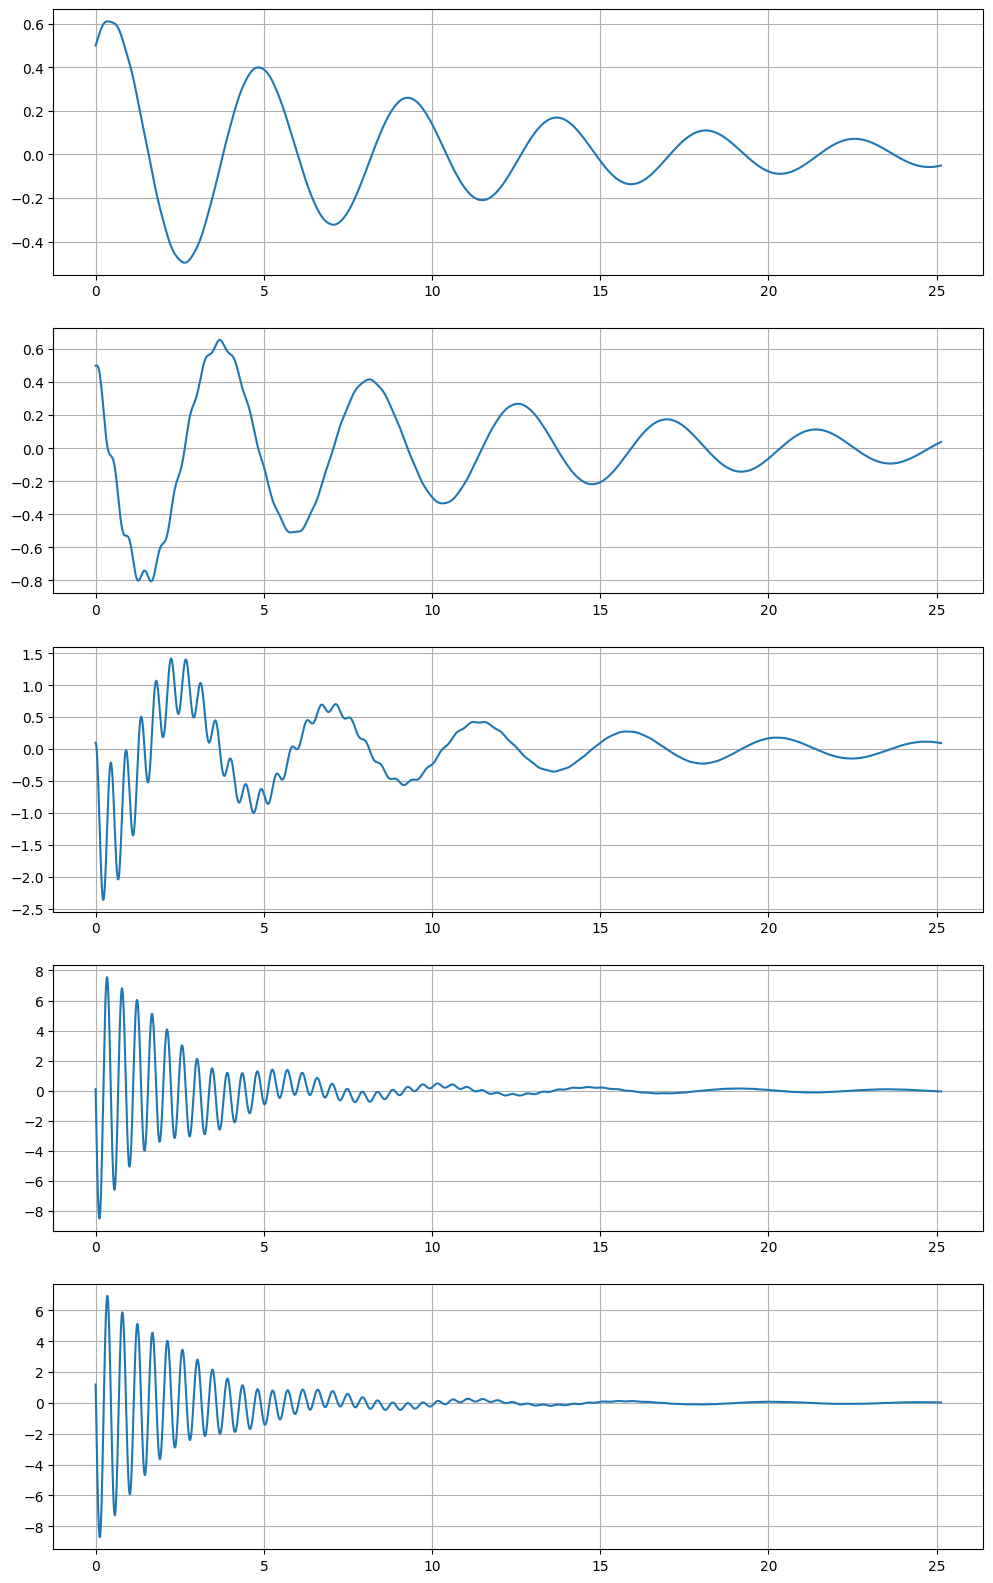

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as la

def signal(t, wg, S11, S12, S21, S22, epsilon):
    w1 = wg[:2]
    w2 = wg[2:]

    dw1 = S11 @ w1 + S12 @ w2
    dw2 = (1/epsilon) * (S21 @ w1 + S22 @ w2)

    return np.concatenate([dw1, dw2])

a = 100.0
b = 10.0
c = 50.0
d = 0.5
epsilon = 0.5

S11 = np.array([[0. , 1.0],
                [0.0, 0.]])
S12 = np.array([[0., 0.],
                [1., 0.]])

S21 = np.array([[0., 0.,],
                [-a, -b]])
S22 = np.array([[0., 1.],
                [-c, -d]])

Sg = np.block([[S11, S12],
               [(1/epsilon) * S21, (1/epsilon) * S22]])
print(Sg)
print(la.eigvals(Sg))



t_span = (0., 8.0*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

w0 = [0.5, 0.5, 0.1, 0.1]
solw = solve_ivp(
    lambda t, state: signal(t, state,
                            S11 = S11,
                            S12 = S12,
                            S21 = S21, 
                            S22 = S22, 
                            epsilon = epsilon),
    t_span,
    w0, 
    t_eval = t_eval,
    method = 'RK45'
)

plt.figure(figsize = (12,20))
Wg = solw.y
for i in range(4):
    Lg = np.zeros(4)
    Lg[i] = 1.0
    plt.subplot(5,1,i+1)
    print(Lg)
    plt.plot(solw.t, (Lg @ Wg).flatten())
    plt.grid(True)

Lg = np.array([1.0 for i in range(4)])
plt.subplot(5,1,5)
plt.plot(solw.t, (Lg@Wg).flatten())
plt.grid(True)
plt.show()
# plt.plot( solw.t, U.flatten())
# #plt.plot( solw.t, (Lgslow @ Wg).flatten())
# plt.plot( solw.t, (Lgslow @ Wg).flatten())
# plt.grid(True)

# plt.show()